In [128]:
from bigraph_viz import plot_bigraph

plot_settings = {
    'out_dir': 'out',
    'dpi': '70',
    'port_label_size': '12pt',
    'node_label_size': '20pt',
    'process_label_size': '20pt',
    'label_margin': '0.1',
    'port_labels': False,
    'undirected_edges': True,
}

Writing out/lung_model


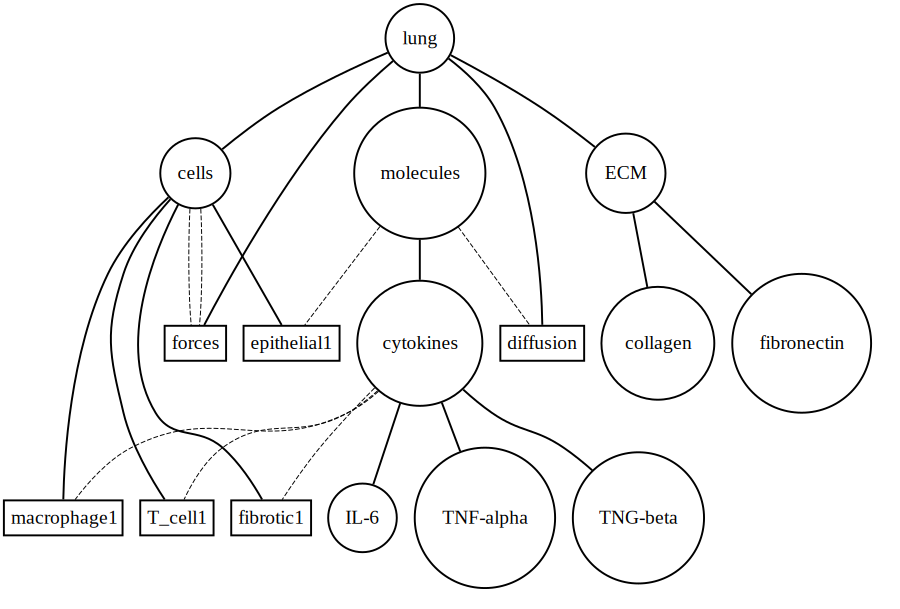

In [129]:
n_epithelial = 1
n_fibrotic = 1
n_immune = 1

epithelial_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules'],
    }
}

fibrotic_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'cytokines'],  # Fibrotic cells interact with cytokines
    }
}

immune_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'cytokines'],  # Immune cells respond to cytokines
    }
}

organoid = {
    'lung': {
        'cells': {
            **{f'epithelial{n}': epithelial_cell for n in range(1, n_epithelial+1)},
            **{f'fibrotic{n}': fibrotic_cell for n in range(1, n_fibrotic+1)},
            **{f'macrophage{n}': immune_cell for n in range(1, n_immune+1)},
            **{f'T_cell{n}': immune_cell for n in range(1, n_immune+1)}
        },
        'molecules': {
            'cytokines': {
                'IL-6': {},
                'TNF-alpha': {},
                'TNG-beta': {},
            }
        },
        # 'cytokines': {},  # New cytokine node
        'ECM': {
            'collagen': {},
            'fibronectin': {}
        },
        'diffusion': {
            '_type': 'process',
            'inputs': {'molecules': ['molecules'],
                       # 'cytokines': ['cytokines']
                       }
        },
        'forces': {
            '_type': 'process',
            'inputs': {'cells': ['cells'],
                       'immune_cells': ['cells']}
        }
    }
}

plot_settings2 = {
    'node_groups': [
        [
            ['lung', 'cells'],
            ['lung', 'molecules'],
            ['lung', 'ECM'],
        ],
    ],
}
# Generate the updated diagram
plot_bigraph(organoid, **plot_settings, **plot_settings2, filename='lung_model')


Writing out/placenta_model


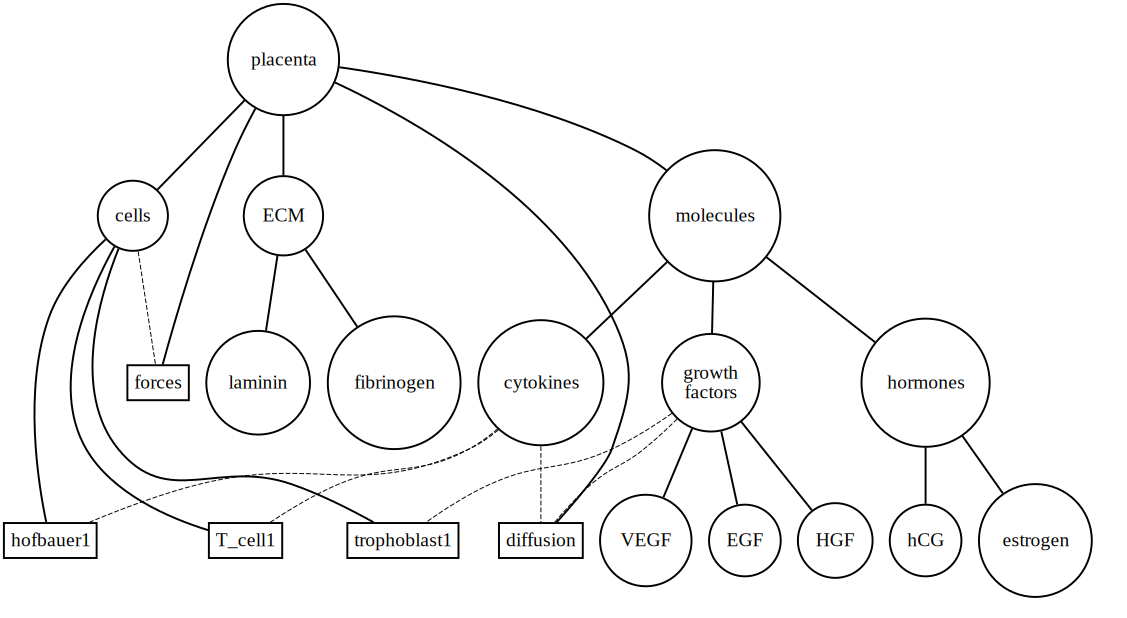

In [130]:
n_trophoblast = 1
n_hofbauer = 1
n_immune = 1

trophoblast_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'growth factors'],  # Trophoblast cells respond to growth factors
    }
}

hofbauer_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'cytokines'],  # Hofbauer cells interact with immune cytokines
    }
}

immune_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'cytokines'],  # Immune cells regulate immune response via cytokines
    }
}

organoid = {
    'placenta': {
        'cells': {
            **{f'trophoblast{n}': trophoblast_cell for n in range(1, n_trophoblast+1)},
            **{f'hofbauer{n}': hofbauer_cell for n in range(1, n_hofbauer+1)},
            **{f'T_cell{n}': immune_cell for n in range(1, n_immune+1)}
        },
        'molecules': {
            'growth factors': {
                'VEGF': {},
                'EGF': {},
                'HGF': {}
            },  # Growth factors important for trophoblast differentiation
            'cytokines': {},  # Cytokines influence immune-trophoblast interaction
            'hormones': {
                'hCG': {},
                'estrogen': {}
            }
        },
        'ECM': {
            'laminin': {},
            'fibrinogen': {},
        },  # Placental ECM component
        'diffusion': {
            '_type': 'process',
            'inputs': {'growth factors': [ 'molecules', 'growth factors'],
                       'cytokines': [ 'molecules', 'cytokines']}
        },
        'forces': {
            '_type': 'process',
            'inputs': {'cells': ['cells']}
        }
    }
}

plot_settings2 = {
    'node_groups': [
        [
            ['placenta', 'cells'],
            ['placenta', 'ECM'],
            ['placenta', 'molecules'],
        ],
    ],
}

# Generate the placenta model diagram
plot_bigraph(organoid, **plot_settings, **plot_settings2, filename='placenta_model')


Writing out/cancer_model


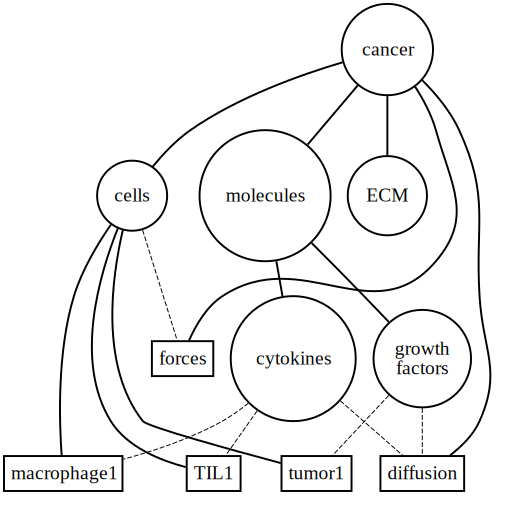

In [131]:
n_tumor = 1
n_macrophage = 1
n_til = 1  # Tumor-infiltrating lymphocytes (TILs)

tumor_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'growth factors'],  # Tumor cells use growth factors for proliferation
    }
}

macrophage_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'cytokines'],  # Tumor-associated macrophages (TAMs) interact with immune signals
    }
}

til_cell = {
    '_type': 'process',
    'inputs': {
        'uptake': ['..', 'molecules', 'cytokines'],  # TILs respond to cytokines for immune activation
    }
}

organoid = {
    'cancer': {
        'cells': {
            **{f'tumor{n}': tumor_cell for n in range(1, n_tumor+1)},
            **{f'macrophage{n}': macrophage_cell for n in range(1, n_macrophage+1)},
            **{f'TIL{n}': til_cell for n in range(1, n_til+1)}
        },
        'molecules': {
            'growth factors': {},  # Growth factors support tumor proliferation
            'cytokines': {},  # Cytokines influence immune-tumor interactions
        },
        'ECM': {},  # Tumor microenvironment
        'diffusion': {
            '_type': 'process',
            'inputs': {'growth factors': ['molecules', 'growth factors'],
                       'cytokines': ['molecules', 'cytokines']}
        },
        'forces': {
            '_type': 'process',
            'inputs': {'cells': ['cells']}
        }
    }
}

plot_settings2 = {
    'node_groups': [
        [
            ['cancer', 'cells'],
            ['cancer', 'molecules'],
            ['cancer', 'ECM'],
        ],
    ],
}

# Generate the cancer model diagram
plot_bigraph(organoid, **plot_settings, **plot_settings2, filename='cancer_model')
